# Two-observer spacetime-diagram tool

[![Open in Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/daanmeerburg/WBPH001-10-Lectures/blob/main/Diagram_Tool/Two_Observer_Diagram_Tool.ipynb)

A small, Colab-friendly tool for constructing diagrams in **$(ct,x)$ coordinates**. Set the boost $\beta=u/c$ below; the $S'$ axes and their tick positions are then obtained from the Lorentz transformation.

Run the setup cell, edit the configuration and drawing cells, then export an SVG or PDF.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

# A dimensionless speed beta=u/c must satisfy |beta|<1.
def gamma(beta):
    if abs(beta) >= 1:
        raise ValueError('beta must satisfy |beta| < 1.')
    return 1 / np.sqrt(1 - beta**2)

def add_event(ax, x, ct, label=None, color='crimson', dx=0.12, dy=0.12):
    ax.plot(x, ct, 'o', color=color, ms=5, zorder=5)
    if label:
        ax.text(x+dx, ct+dy, label, color=color)

def add_worldline(ax, x0, ct0, beta, ct_range=(-6, 6), label=None, **style):
    """Worldline x=x0+beta(ct-ct0); beta=0 gives a stationary object."""
    ct = np.array(ct_range)
    x = x0 + beta*(ct-ct0)
    line, = ax.plot(x, ct, **({'lw': 2} | style))
    if label:
        ax.text(x[-1]+0.08, ct[-1], label, color=line.get_color())
    return line

def add_light_ray(ax, x0, ct0, direction=1, ct_range=(-6, 6), label=None, **style):
    """A light ray has beta=+1 (right) or -1 (left)."""
    return add_worldline(ax, x0, ct0, direction, ct_range, label, ls='--', **style)

def add_world_region(ax, x_left_at_reference, width, beta, reference_ct=0, ct_range=None,
                     label=None, color='tab:orange', edgecolor=None, alpha=0.18,
                     label_ct=None, label_color='black', label_size=12):
    """Draw a coloured finite world region between two endpoint worldlines.

    x_left_at_reference is the left/rear endpoint at ct=reference_ct, not at
    the bottom of the page. If ct_range is omitted, the region automatically
    spans the entire visible diagram.
    """
    if ct_range is None:
        ct_bottom, ct_top = ax.get_ylim()
    else:
        ct_bottom, ct_top = ct_range
    edgecolor = color if edgecolor is None else edgecolor
    def left_edge(ct):
        return x_left_at_reference + beta*(ct-reference_ct)
    points = [(left_edge(ct_bottom), ct_bottom), (left_edge(ct_bottom)+width, ct_bottom),
              (left_edge(ct_top)+width, ct_top), (left_edge(ct_top), ct_top)]
    patch = Polygon(points, closed=True, facecolor=color, edgecolor=edgecolor, alpha=alpha, zorder=2)
    ax.add_patch(patch)
    add_worldline(ax, left_edge(ct_bottom), ct_bottom, beta, (ct_bottom, ct_top), color=edgecolor, zorder=3)
    add_worldline(ax, left_edge(ct_bottom)+width, ct_bottom, beta, (ct_bottom, ct_top), color=edgecolor, zorder=3)
    if label:
        ct_label = (ct_bottom+ct_top)/2 if label_ct is None else label_ct
        x_label = left_edge(ct_label) + width/2
        ax.text(x_label, ct_label, label, ha='center', va='center', fontsize=label_size,
                fontweight='bold', color=label_color, zorder=6,
                bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor=edgecolor, alpha=0.92))
    return patch

def add_train_region(ax, rear_x0, length, beta, ct0=0, ct1=5, **kwargs):
    """Compatibility name; prefer add_world_region for any extended object."""
    return add_world_region(ax, rear_x0, length, beta, reference_ct=ct0, ct_range=(ct0, ct1), **kwargs)


## Hyperbolic paper

The function below draws Minkowski graph paper: the faint curves are the invariant hyperbolae $ (ct-ct_0)^2-(x-x_0)^2=\pm\rho^2 $. It also draws the light cone, the two coordinate systems, and correctly placed $S'$ ticks.

In [2]:
def two_observer_hyperbolic_paper(beta=0.6, size=6, symmetric=True, origin=(0, 0),
                                   grid_dimensions=(5, 5), tick_step=1, labels=True):
    """Draw two-observer Minkowski (hyperbolic) paper in (ct,x) coordinates.

    Parameters
    ----------
    beta : float
        Relative speed u/c of S' along +x.
    size : number or ((left,right),(down,up))
        With symmetric=True, a number gives the half-width and half-height;
        a pair (x_size, ct_size) permits a rectangular paper. With
        symmetric=False, give distances from origin as ((left,right),(down,up)).
    symmetric : bool
        Draw equal extents on both sides of origin when True.
    origin : (x0, ct0)
        Position of the shared S/S' origin on the page.
    grid_dimensions : (n_timelike, n_spacelike)
        Number of positive invariant hyperbolae in each family.
    """
    g = gamma(beta)
    x0, ct0 = origin
    if symmetric:
        sx, st = (size, size) if np.isscalar(size) else size
        xlim, ctlim = (x0-sx, x0+sx), (ct0-st, ct0+st)
    else:
        (left, right), (down, up) = size
        xlim, ctlim = (x0-left, x0+right), (ct0-down, ct0+up)
    n_time, n_space = grid_dimensions

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(*xlim); ax.set_ylim(*ctlim)
    ax.set_xticks([]); ax.set_yticks([])

    # The invariant hyperbolae are the hyperbolic graph paper.
    xr = np.linspace(xlim[0]-x0, xlim[1]-x0, 900)
    tr = np.linspace(ctlim[0]-ct0, ctlim[1]-ct0, 900)
    axis_extent = max(max(abs(xr)), max(abs(tr))) * 1.5
    paper_style = dict(color='0.82', lw=0.7, zorder=0)
    # Calibrated paper: rho=nL, so every hyperbola meets its matching tick.
    for rho in tick_step*np.arange(1, n_time+1):
        y = np.sqrt(rho**2 + xr**2)
        for sign in ([1, -1] if symmetric else [1]):
            yy = ct0 + sign*y
            ax.plot(x0+xr, np.where((yy >= ctlim[0]) & (yy <= ctlim[1]), yy, np.nan), **paper_style)
    for rho in tick_step*np.arange(1, n_space+1):
        x = np.sqrt(rho**2 + tr**2)
        for sign in ([1, -1] if symmetric else [1]):
            xx = x0 + sign*x
            ax.plot(np.where((xx >= xlim[0]) & (xx <= xlim[1]), xx, np.nan), ct0+tr, **paper_style)

    # S axes and the light cone through the chosen origin.
    ax.axhline(ct0, color='black', lw=1.3); ax.axvline(x0, color='black', lw=1.3)
    z = np.linspace(-axis_extent, axis_extent, 500)
    ax.plot(x0+z, ct0+z, color='0.55', ls=':', lw=1)
    ax.plot(x0+z, ct0-z, color='0.55', ls=':', lw=1)

    # S' axes: x-x0=beta(ct-ct0) and ct-ct0=beta(x-x0).
    ax.plot(x0+beta*z, ct0+z, color='tab:blue', lw=1.8)
    ax.plot(x0+z, ct0+beta*z, color='tab:blue', lw=1.8)

    # Unprimed ticks, at the same calibrated interval L=tick_step.
    x_ticks = range(int(np.ceil((xlim[0]-x0)/tick_step)), int(np.floor((xlim[1]-x0)/tick_step))+1)
    ct_ticks = range(int(np.ceil((ctlim[0]-ct0)/tick_step)), int(np.floor((ctlim[1]-ct0)/tick_step))+1)
    for n in x_ticks:
        if n != 0:
            x = x0+n*tick_step
            ax.plot([x, x], [ct0-0.10, ct0+0.10], color='black', lw=1)
    for n in ct_ticks:
        if n != 0:
            ct = ct0+n*tick_step
            ax.plot([x0-0.10, x0+0.10], [ct, ct], color='black', lw=1)

    # Primed ticks from the inverse Lorentz transformation, also at nL.
    nmax = max(n_time, n_space)
    normal_ct = np.array([1, -beta]); normal_ct /= np.linalg.norm(normal_ct)
    normal_x = np.array([-beta, 1]); normal_x /= np.linalg.norm(normal_x)
    for n in range(-nmax, nmax+1):
        if n == 0: continue
        tick_points = []
        if abs(n) <= n_time:
            tick_points.append((x0+g*beta*n*tick_step, ct0+g*n*tick_step, normal_ct))
        if abs(n) <= n_space:
            tick_points.append((x0+g*n*tick_step, ct0+g*beta*n*tick_step, normal_x))
        for x, ct, normal in tick_points:
            if xlim[0] <= x <= xlim[1] and ctlim[0] <= ct <= ctlim[1]:
                d = 0.10*normal
                ax.plot([x-d[0], x+d[0]], [ct-d[1], ct+d[1]], color='tab:blue', lw=1)

    # Find the visible end of any axis ray, then place its label just inside it.
    # This keeps labels bound to the paper when its size, symmetry, or origin changes.
    def axis_label_point(dx, dct, fraction=0.94):
        candidates = []
        if dx > 0: candidates.append((xlim[1]-x0)/dx)
        if dx < 0: candidates.append((xlim[0]-x0)/dx)
        if dct > 0: candidates.append((ctlim[1]-ct0)/dct)
        if dct < 0: candidates.append((ctlim[0]-ct0)/dct)
        distance = min(value for value in candidates if value >= 0)
        return x0 + fraction*distance*dx, ct0 + fraction*distance*dct

    if labels:
        x_label = axis_label_point(1, 0)
        ct_label = axis_label_point(0, 1)
        xp_label = axis_label_point(1, beta)
        ctp_label = axis_label_point(beta, 1)
        ax.text(*x_label, '$x$', ha='right', va='bottom')
        ax.text(*ct_label, '$ct$', ha='left', va='top')
        ax.text(*xp_label, "$x'$", color='tab:blue', ha='right', va='bottom')
        ax.text(*ctp_label, "$ct'$", color='tab:blue', ha='left', va='top')
    return fig, ax


## Configuration
Change `beta`, the plotting range, and the tick separation. The blue ticks represent equal intervals of either $ct'$ or $x'$; they are not equally spaced in the unprimed coordinates.

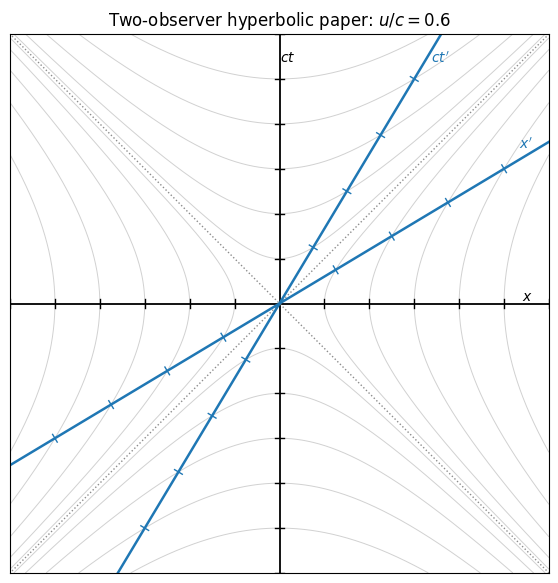

In [3]:
beta = 3/5                   # speed u/c of S' relative to S
size = (6, 6)                # half-size in (x, ct), when symmetric=True
symmetric = True              # False: size=((left,right),(down,up))
origin = (0, 0)              # (x0, ct0), the common S/S' origin
grid_dimensions = (10, 10)     # (timelike hyperbolae, spacelike hyperbolae)
tick_step = 1                # one primed-coordinate unit per tick

fig, ax = two_observer_hyperbolic_paper(beta, size, symmetric, origin,
                                        grid_dimensions, tick_step)
ax.set_title(f'Two-observer hyperbolic paper: $u/c={beta:g}$')
plt.show()

## Add events, worldlines, light rays, and a world region
The example below can be replaced freely. Coordinates supplied to the helper functions are always $(x,ct)$ in frame $S$. A worldline has `beta = dx/d(ct) = v/c`.

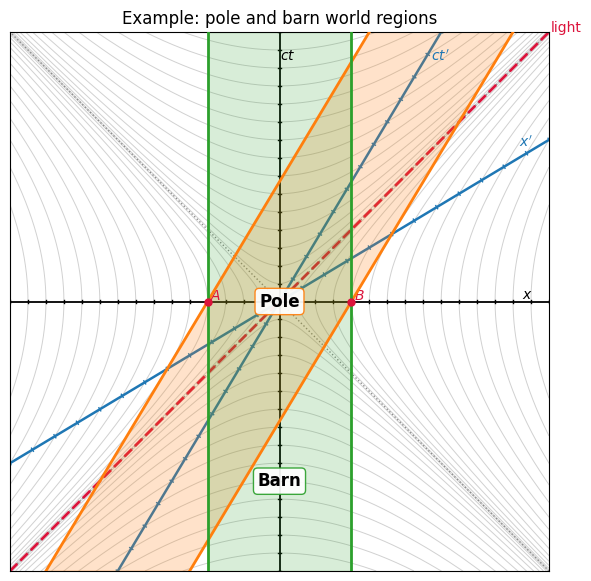

In [4]:
# Start with fresh hyperbolic paper.
fig, ax = two_observer_hyperbolic_paper(beta=3/5, size=(15, 15), symmetric=True,
                                        origin=(0, 0), grid_dimensions=(15, 15), tick_step=1)

# Events: add_event(ax, x, ct, label)
add_event(ax, -4, 0, '$A$')
add_event(ax,  4, 0, '$B$')

# Worldlines: x=x0+beta_line(ct-ct0)
#add_worldline(ax, x0=-3, ct0=0, beta=0, ct_range=(-1, 5), label='platform clock', color='black')
#add_worldline(ax, x0=-2, ct0=0, beta=3/5, ct_range=(-1, 6), label='traveller', color='tab:orange')

# Light rays (direction +1 is rightward, -1 is leftward).
add_light_ray(ax, x0=0, ct0=0, direction=1, ct_range=(-15, 15), label='light', color='crimson')

# World regions automatically span the full diagram when ct_range is omitted.
# The pole's rear is at x=-4 at ct=0; its x=-13 position at ct=-15 is calculated automatically.
add_world_region(ax, x_left_at_reference=-4, width=8, beta=3/5, reference_ct=0,
                 label='Pole', color='tab:orange', alpha=0.22)
add_world_region(ax, x_left_at_reference=-4, width=8, beta=0, reference_ct=0,
                 label='Barn', color='tab:green', alpha=0.18, label_ct=-10)


ax.set_title('Example: pole and barn world regions')
plt.show()

# Vector exports are best for lecture notes and slides.
# fig.savefig('two_observer_diagram.svg', bbox_inches='tight')
# fig.savefig('two_observer_diagram.pdf', bbox_inches='tight')

## Conventions and checks

- The horizontal coordinate is $x$ and the vertical coordinate is $ct$.
- $S'$ moves in the positive $x$ direction at $u=\beta c$.
- The $ct'$ axis is the worldline $x'=0$, i.e. $x=\beta ct$. The $x'$ axis is $ct'=0$, i.e. $ct=\beta x$.
- Tick positions use the inverse Lorentz transformation: a $ct'=L$ tick is $(ct,x)=(\gamma L,\gamma\beta L)$; an $x'=L$ tick is $(ct,x)=(\gamma\beta L,\gamma L)$.
- This notebook intentionally does not infer the physics of a diagram from its appearance. Specify the events and frame conditions first.